<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/ESAA_0615_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN 개요

DBSCAN

: 밀도 기반 군집화의 대표적 알고리즘

: 특정 공간 내에 데이터 밀도 차이를 기반 알고리즘으로 군집화 수행

: 간단하고 직관적인 알고리즘

: 데이터의 분포가 기하학적으로 복잡한 데이터 세트에도 효과적인 군집화 가능

- 주요 파라미터

입실론 주변 영역(epsilon)

: 개별 데이터를 중심으로 입실론 반경을 가지는 원형의 영역

최소 데이터 개수(min points)

: 개별 데이터의 입실론 주변 영역에 포함되는 타 데이터의 개수

- 데이터 포인트의 정의

기준: 입실론 주변 영역 내에 포함되는 최소 데이터 개수를 충족시키는지 아닌지

핵심 포인트(Core Point): 주변 영역 내에 최소 데이터 개수 이상의 타 데이터를 가지고 있는 경우의 해당 데이터

이웃 포인트(Neighbor Point): 주변 영역 내에 위치한 타 데이터

경계 포인트(Border Point): 주변 영역 내에 최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않지만 핵심 포인트를 이웃 포인트로 가지고 있는 데이터

잡음 포인트(Noise Point):  최소 데이터 개수 이상의 이웃 포인트를 가지고 있지 않으며, 핵심 포인트도 이웃 포인트로 가지고 있지 않는 데이터

-> DBSCAN: 입실론 주변 영역의 최소 데이터 개수를 포함하는 밀도 기준을 충족시키는 데이터인 핵심 포인트를 연결하면서 군집화를 구성하는 방식

사이킷런의 DBSCAM 클래스

eps: 입실론 주변 영역의 반경

min_samples: 핵심 포인트가 되기 위해 입실론 주변 영역 내에 포함돼야 할 최소 개수 (자신의 개수 포함)

# DBSCAM 적용하기 - 붓꽃 데이터 세트

붓꽃 데이터 세트를 DataFrame으로 로딩

eps=0.6, min_samples=8로 설정

(일반적으로 eps 값은 1이하의 값 설정)


dbscan_cluster 값: 0, 1 외에 -1이 군집 레이블로 존재

*군집 레이블이 -1: 노이즈에 속하는 군집

--> 붓꽃 데이터 세트는 0과 1 두 개의 군집을 군집화

visualize_cluster_plot(): PCA를 이용하여 데이터 세트를 2개의 피터로 압축

(데이터 세트를 2차원에 표현하기위해)

(irisDF의 'ftr1', 'ftr2' 칼럼에 PCA로 변환된 피처 데이터 세트 입력)

eps값 증가 -> 노이즈 데이터 개수 감소

min_samples 값 증가 -> 노이제 데이터 개수 증가

eps=0.8, min_samples=8

-> 수행 결과: 노이즈 군집 3개

eps 기존 0.6 유지, min_samples=16

-> 수행 결과: 노이즈 데이터 수 증가

# DBSCAM 적용하기 - make_circles() 데이터 세트

DBSCAM과 타알고리즘 비교

make_circles(): 내부 원, 외부 원 형태로 돼 있는 2차원 데이터 세트 생성

- 파라미터

noise: 노이즈 데이터 세트의 비율

factor: 외부 원, 내부 원의 scale 비율

- K-평균의 데이터 군집화 과정

위, 아래 군집 중심을 기반으로 위, 아래 절반으로 군집화

데이터가 특정한 형태로 지속해서 이어지는 부분 찾아내기 어려움.

- GMM의 데이터 군집화 과정

K-평균으로 수행 시 일렬로 늘어선 데이터 세트에서는 효과적으로 군집화 적용 가능

내부, 외부의 원형으로 구성된 더 복잡한 형태의 데이터 세트에서는 군집화가 원하는 방향으로 수행 X

- DBSCAN의 데이터 군집화 과정

원하는 방향으로 정확히 군집화됨.








In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the iris dataset
iris=load_iris()

# Create a DataFrame for iris data
irisDF=pd.DataFrame(data=iris.data, columns=iris.feature_names)



In [3]:
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
dbscan_labels=dbscan.fit_predict(iris.data)
irisDF['dbscan_cluster']=dbscan_labels
irisDF['target']=iris.target

iris_result=irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
  if dataframe is None:
    print("Error: DataFrame is required.")
    return

    unique_labels=np.unique(dataframe[label_name])
    markers=['o','s','^','x','*','D','+','v','<','>']

    for label in unique_labels:
      label_cluster=dataframe[dataframe[label_name]==label]
      plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
              marker=markers[label%len(markers)])

      if iscenter and cluster_result is not None and hasattr(cluster_result,'cluster_centers_'):
         # Assuming cluster_result has a .cluster_centers_attribute
         center_x_y=cluster_result.cluster_centers_[labels]
         plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                     marker=markers[label%len(markers)])

         plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
                marker='$%d$'%label)

         plt.show()

In [10]:
from sklearn.decomposition import PCA

# 2차원으로 시각화하기 위해 PCA n_colponents=2로 피처 데이터 세트 변환
pca=PCA(n_components=2, random_state=0)
pca_transformed=pca.fit_transform(iris.data)

# visualize_clster_plot() 함수는 ftr1, ftr2  칼럼을 좌표에 표현하므로 PCA 변환값을 해당 칼럼으로 생성
irisDF['ftr1']=pca_transformed[:,0]
irisDF['ftr2']=pca_transformed[:,1]

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

In [12]:
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.8, min_samples=8, metric='euclidean')
dbscan_labels=dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster']=dbscan_labels
irisDF['target']=iris.target

iris_result=irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


In [13]:
dbscan=DBSCAN(eps=0.6, min_samples=16, metric='euclidean')

In [17]:
from sklearn.datasets import make_circles

X,y=make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF=pd.DataFrame(data=X, columns=['ftr1','ftr2'])
clusterDF['target']=y

visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

In [19]:
# KMeans로 make_circles() 데이터 세트를 군집화 수행.
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels=kmeans.fit_predict(X)
clusterDF['kmeans_cluster']=kmeans_labels

visualize_cluster_plot(kmeans,clusterDF,'kmeans_cluster',iscenter=True)

In [21]:
# GMM으로 make_circles() 데이터 세트를 군집화 수행.
from sklearn.mixture import GaussianMixture

gmm=GaussianMixture(n_components=2, random_state=0)
gmm_label=gmm.fit_predict(X)
clusterDF['gmm_cluster']=gmm_label

visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)

In [24]:
# DBSCAM으로 make_circles() 데이터 세트 군집화 수행.
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels=dbscan.fit_predict(X)
clusterDF['dbscan_cluster']=dbscan_labels
visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

In [25]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

retail_df=pd.read_excel(io='Online Retail.xlsx')
retail_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [26]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [27]:
retail_df=retail_df[retail_df['Quantity']>0]
retail_df=retail_df[retail_df['Quantity']>0]
retail_df=retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397924, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [28]:
retail_df['Country'].value_counts()[:5]

,count
Country,
United Kingdom,354345
Germany,9042
France,8342
EIRE,7238
Spain,2485


In [29]:
retail_df=retail_df[retail_df['Country']=='United Kingdom']
print(retail_df.shape)

(354345, 8)


In [31]:
retail_df['sale_amount']=retail_df['Quantity']*retail_df['UnitPrice']
retail_df['CustomerID']=retail_df['CustomerID'].astype(int)
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5])

CustomerID
17841    7847
14096    5111
12748    4596
14606    2700
15311    2379
Name: count, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


/tmp/ipykernel_4007/4248279440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail_df['sale_amount']=retail_df['Quantity']*retail_df['UnitPrice']
/tmp/ipykernel_4007/4248279440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail_df['CustomerID']=retail_df['CustomerID'].astype(int)


In [34]:
retail_df.groupby(['InvoiceNo', 'StockCode'])['InvoiceNo'].count().mean()

np.float64(1.0287120233412201)

In [36]:
# DataFrame의 groupby()의 multiplt 연산을 위해 agg() 이용
# Requency는 InvoiceDate 칼럼의 max()에서 데이터 가공
# Frequency는 InvoiceNo 칼럼의 count(), Monetary value는 sale_amount 칼럼의 sum()
aggregations={
    'InvoiceDate':'max',
    'InvoiceNo': 'count',
    'sale_amount':'sum'
}
cust_df=retail_df.groupby('CustomerID').agg(aggregations)
# groupby된 결과 칼럼 값을 Recency, Frequency, Monetary로 변경
cust_df=cust_df.rename(columns={'InvoiceDate':'Recency',
                                'InvoiceNo':'Frequency',
                                'sale_amount':'Monetary'
}
)
cust_df=cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4596,33719.73


In [38]:
import datetime as dt

cust_df['Recency']=dt.datetime(2011,12,10)-cust_df['Recency']
cust_df['Recency']=cust_df['Recency'].apply(lambda x:x.days+1)
print('cust_df 로우와 칼럼 건수는', cust_df.shape)
cust_df.head(3)

cust_df 로우와 칼럼 건수는 (3921, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4596,33719.73


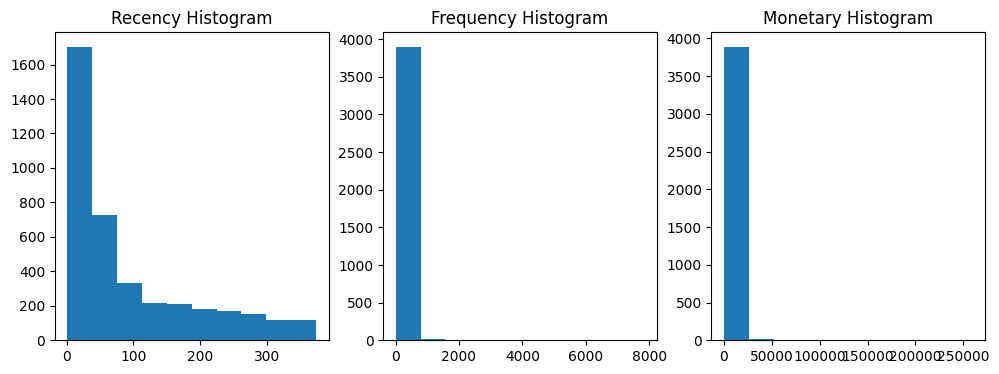

In [40]:
fig, (ax1,ax2,ax3)=plt.subplots(figsize=(12,4), nrows=1, ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

X_features=cust_df[['Recency','Frequency','Monetary']].values
X_features_scaled=StandardScaler().fit_transform(X_features)

kmeans=KMeans(n_clusters=3, random_state=0)
labels=kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label']=labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))


실루엣 스코어는: 0.592


In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA


def visualize_silhouette(cluster_lists, X_features):

    # Visualize Silhouette for each cluster
    n_cols = len(cluster_lists)

    fig, axs = plt.subplots(
        figsize=(4 * n_cols, 4),
        nrows=1,
        ncols=n_cols
    )

    for ind, n_cluster in enumerate(cluster_lists):

        kmeans = KMeans(
            n_clusters=n_cluster,
            max_iter=500,
            random_state=0,
            n_init='auto'
        )

        cluster_labels = kmeans.fit_predict(X_features)

        silhouette_avg = silhouette_score(
            X_features,
            cluster_labels
        )

        sample_silhouette_values = silhouette_samples(
            X_features,
            cluster_labels
        )

        y_lower = 10

        axs[ind].set_title(
            'Number of Cluster : ' + str(n_cluster)
            + '\nSilhouette Score : '
            + str(round(silhouette_avg, 3))
        )

        axs[ind].set_xlabel(
            "The silhouette coefficient values"
        )
        axs[ind].set_ylabel("Cluster label")

        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim(
            [0, len(X_features) + (n_cluster + 1) * 10]
        )

        axs[ind].set_yticks([])
        axs[ind].set_xticks(
            [0, 0.2, 0.4, 0.6, 0.8, 1]
        )

        for i in range(n_cluster):

            ith_cluster_silhouette_values = (
                sample_silhouette_values[
                    cluster_labels == i
                ]
            )

            ith_cluster_silhouette_values.sort()

            size_cluster_i = (
                ith_cluster_silhouette_values.shape[0]
            )

            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(
                float(i) / n_cluster
            )

            axs[ind].fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            axs[ind].text(
                -0.05,
                y_lower + 0.5 * size_cluster_i,
                str(i)
            )

            y_lower = y_upper + 10

        axs[ind].axvline(
            x=silhouette_avg,
            color="red",
            linestyle="--"
        )

    plt.tight_layout()
    plt.show()


def visualize_kmeans_plot_multi(
        cluster_lists,
        X_features,
        iscenter=False):

    n_cols = len(cluster_lists)

    fig, axs = plt.subplots(
        figsize=(4 * n_cols, 4),
        nrows=1,
        ncols=n_cols
    )

    pca = PCA(
        n_components=2,
        random_state=0
    )

    pca_transformed = pca.fit_transform(
        X_features
    )

    dataframe = pd.DataFrame(
        data=pca_transformed,
        columns=['ftr1', 'ftr2']
    )

    markers = [
        'o', 's', '^', 'x', '*',
        'D', '+', 'v', '<', '>'
    ]

    for ind, n_cluster in enumerate(cluster_lists):

        kmeans = KMeans(
            n_clusters=n_cluster,
            max_iter=500,
            random_state=0,
            n_init='auto'
        )

        cluster_labels = kmeans.fit_predict(
            X_features
        )

        dataframe['cluster'] = cluster_labels

        unique_labels = np.unique(
            dataframe['cluster']
        )

        for label in unique_labels:

            label_cluster = dataframe[
                dataframe['cluster'] == label
            ]

            axs[ind].scatter(
                x=label_cluster['ftr1'],
                y=label_cluster['ftr2'],
                edgecolor='k',
                marker=markers[
                    label % len(markers)
                ]
            )

        if (
            iscenter and
            hasattr(kmeans, 'cluster_centers_')
        ):

            center_x_y = pca.transform(
                kmeans.cluster_centers_
            )

            for label, center in enumerate(
                    center_x_y):

                axs[ind].scatter(
                    x=center[0],
                    y=center[1],
                    s=200,
                    color='gray',
                    alpha=0.9,
                    marker=markers[
                        label % len(markers)
                    ]
                )

                axs[ind].scatter(
                    x=center[0],
                    y=center[1],
                    s=70,
                    color='k',
                    edgecolor='k',
                    marker='$%d$' % label
                )

        axs[ind].set_title(
            'Number of Cluster : '
            + str(n_cluster)
        )

        axs[ind].set_xlabel('ftr1')
        axs[ind].set_ylabel('ftr2')

    plt.tight_layout()
    plt.show()

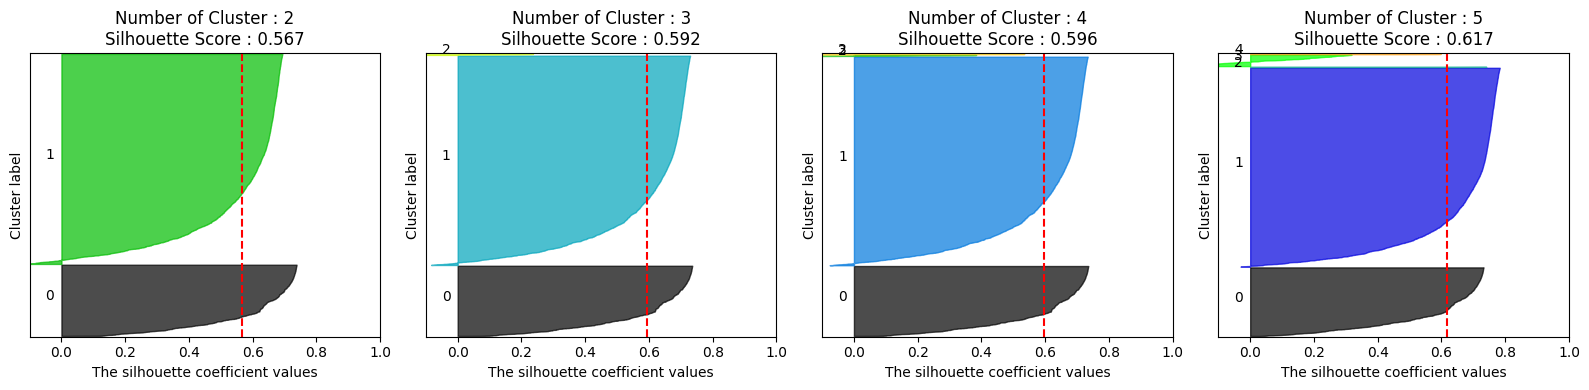

/tmp/ipykernel_4007/1527983714.py:170: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(
/tmp/ipykernel_4007/1527983714.py:170: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(


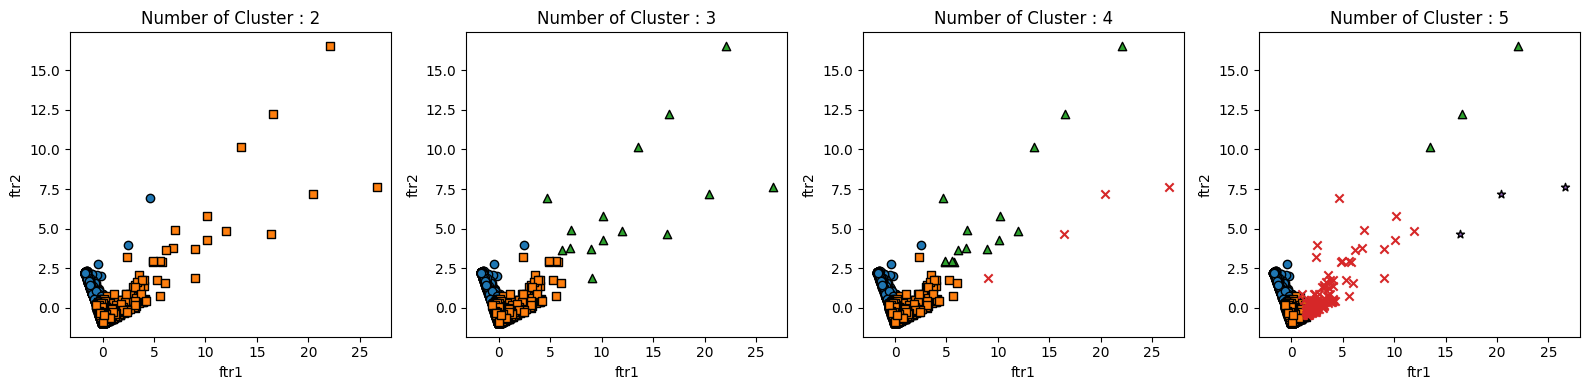

In [45]:
visualize_silhouette([2,3,4,5], X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5], X_features_scaled)

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Recency, Frequency, Monetary 칼럼에 np.log1p()로 Log Transformation
cust_df['Recency_log']=np.log1p(cust_df['Recency'])
cust_df['Frequency_log']=np.log1p(cust_df['Frequency'])
cust_df['Monetary_log']=np.log1p(cust_df['Monetary'])

# Log Transformation 데이터에 StandardScaler 적용
X_features=cust_df[['Recency_log','Frequency_log','Monetary_log']].values
X_features_sclaed=StandardScaler().fit_transform(X_features)

kmeans=KMeans(n_clusters=3, random_state=0)
labels=kmeans.fit_predict(X_features_sclaed)
cust_df['cluster_label']=labels

print('실루엣 스코어는: {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

실루엣 스코어는: 0.157
